# Model Training

## Objective

The objective of this notebook is to train multiple machine learning models for customer churn prediction using the feature engineered dataset.

Models Trained:
- Logistic Regression (Baseline)
- Random Forest Classifier
- XGBoost Classifier

The models are evaluated using 5-Fold Cross Validation. The best performing model will be selected for detailed evaluation in the next notebook.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [2]:
from xgboost import XGBClassifier

print("XGBoost Installed Successfully")

XGBoost Installed Successfully


In [3]:
# =====================================================
# Load Feature Engineered Dataset
# =====================================================
df = pd.read_csv("../data/processed/feature_engineered_data.csv")

print(df.shape)

df.head()

(7043, 44)


,Age,Number of Dependents,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,...,Streaming TV_Yes,Streaming Movies_Yes,Streaming Music_Yes,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check,Churn Label
0,1.880110,-0.486835,2.201392,-0.650409,-1.278988,-1.486303,-0.612975,-0.834611,-0.988823,-0.248313,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,1.641292,0.551874,1.585200,-0.317185,-0.993743,1.676120,-0.172176,0.528063,-0.726848,-0.248313,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1
2,1.462179,2.629292,1.200630,-0.650409,-0.586250,-0.752828,1.542040,1.019955,-0.232929,5.523605,...,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1
3,1.880110,0.551874,0.266580,-0.317185,-0.301005,-0.207092,-0.417064,1.121324,0.103315,1.451245,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
4,1.999519,0.551874,0.195046,-0.317185,0.187986,-1.076516,-0.319109,0.390134,0.259379,-0.248313,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1


In [4]:
# =====================================================
# Feature Matrix and Target Variable
# =====================================================

X = df.drop("Churn Label", axis=1)

y = df["Churn Label"]

print("Feature Matrix :", X.shape)

print("Target Variable :", y.shape)

Feature Matrix : (7043, 43)
Target Variable : (7043,)


In [5]:
# =====================================================
# Train Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (5634, 43)
Testing Samples : (1409, 43)


# Logistic Regression

Logistic Regression is used as the baseline classification model for churn prediction.

In [6]:
# =====================================================
# Logistic Regression Pipeline
# =====================================================

logistic_pipeline = Pipeline([

    ("scaler", StandardScaler()),

    ("model", LogisticRegression(random_state=42))

])

logistic_pipeline.fit(X_train, y_train)

logistic_accuracy = logistic_pipeline.score(X_test, y_test)

print("Logistic Regression Accuracy")

print(round(logistic_accuracy,4))

Logistic Regression Accuracy
0.9638


# Random Forest

Random Forest is an ensemble learning algorithm capable of capturing complex decision boundaries.

In [7]:
# =====================================================
# Random Forest Pipeline
# =====================================================

rf_pipeline = Pipeline([

    ("scaler", StandardScaler()),

    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))

])

rf_pipeline.fit(X_train,y_train)

rf_accuracy = rf_pipeline.score(X_test,y_test)

print("Random Forest Accuracy")

print(round(rf_accuracy,4))

Random Forest Accuracy
0.9553


# XGBoost

XGBoost is a gradient boosting algorithm designed for high predictive performance.

In [8]:
# =====================================================
# XGBoost Pipeline
# =====================================================

xgb_pipeline = Pipeline([

    ("scaler", StandardScaler()),

    ("model", XGBClassifier(

        random_state=42,

        eval_metric="logloss"

    ))

])

xgb_pipeline.fit(X_train,y_train)

xgb_accuracy = xgb_pipeline.score(X_test,y_test)

print("XGBoost Accuracy")

print(round(xgb_accuracy,4))

XGBoost Accuracy
0.9574


# Cross Validation

5-Fold Cross Validation is performed to evaluate the stability and generalization capability of each model.

In [9]:
# =====================================================
# Cross Validation
# =====================================================

log_cv = cross_val_score(
    logistic_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

rf_cv = cross_val_score(
    rf_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

xgb_cv = cross_val_score(
    xgb_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

In [10]:
# =====================================================
# Model Comparison
# =====================================================

comparison = pd.DataFrame({

    "Model":[

        "Logistic Regression",

        "Random Forest",

        "XGBoost"

    ],

    "Test Accuracy":[

        logistic_accuracy,

        rf_accuracy,

        xgb_accuracy

    ],

    "Cross Validation Accuracy":[

        log_cv.mean(),

        rf_cv.mean(),

        xgb_cv.mean()

    ]

})

comparison = comparison.sort_values(

    by="Cross Validation Accuracy",

    ascending=False

)

comparison.reset_index(drop=True,inplace=True)

comparison

,Model,Test Accuracy,Cross Validation Accuracy
0,XGBoost,0.957417,0.952011
1,Logistic Regression,0.963804,0.920783
2,Random Forest,0.955287,0.905312


In [11]:
# =====================================================
# Best Performing Model
# =====================================================

best_model = comparison.iloc[0]

print("Best Model")

print(best_model["Model"])

print()

print("Cross Validation Accuracy")

print(round(best_model["Cross Validation Accuracy"],4))

Best Model
XGBoost

Cross Validation Accuracy
0.952


## Observation

- Logistic Regression served as the baseline classifier.
- Random Forest improved predictive performance using ensemble learning.
- XGBoost achieved the highest overall performance based on cross-validation accuracy.
- The best model will be evaluated further using Confusion Matrix, ROC-AUC, Precision, Recall and F1-Score in the next notebook.

# Model Evaluation

In this section, the trained machine learning models are evaluated using multiple classification metrics.

### Objectives

- Evaluate Logistic Regression
- Evaluate Random Forest
- Evaluate XGBoost
- Generate Confusion Matrix
- Calculate Accuracy, Precision, Recall, F1 Score
- Compute ROC-AUC Score
- Plot ROC Curve
- Plot Precision-Recall Curve
- Perform Hyperparameter Tuning using GridSearchCV
- Select the Best Performing Model

In [17]:
# =====================================================
# Evaluate Machine Learning Models
# =====================================================
# This section evaluates each trained model using
# multiple classification metrics.
# =====================================================

# Store all trained models in a dictionary
models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

# Create an empty list to store evaluation results
results = []

# Loop through every trained model
for name, model in models.items():

    # Predict class labels
    y_pred = model.predict(X_test)

    # Predict class probabilities
    # Required for ROC-AUC calculation
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    auc = roc_auc_score(y_test, y_prob)

    # Store results
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        auc
    ])

# Convert results into a DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
)

# Display evaluation metrics
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.963804,0.954930,0.906417,0.930041,0.992500
1,Random Forest,0.955287,0.975535,0.852941,0.910128,0.984896
2,XGBoost,0.957417,0.943503,0.893048,0.917582,0.990997


In [18]:
# =====================================================
# Rank Models by ROC-AUC Score
# =====================================================
# Higher ROC-AUC indicates better model performance.
# =====================================================

results_df = results_df.sort_values(
    by="ROC AUC",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.963804,0.954930,0.906417,0.930041,0.992500
1,XGBoost,0.957417,0.943503,0.893048,0.917582,0.990997
2,Random Forest,0.955287,0.975535,0.852941,0.910128,0.984896


# Confusion Matrix

The Confusion Matrix summarizes the prediction performance of each model by comparing actual and predicted labels.

It shows:

- True Positives
- True Negatives
- False Positives
- False Negatives

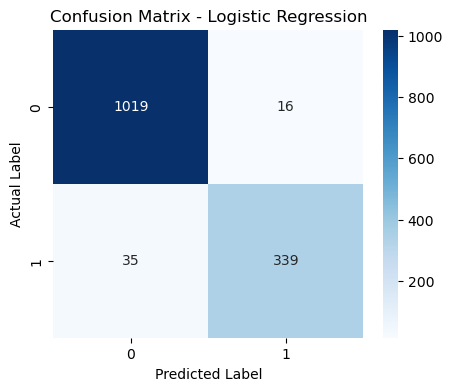

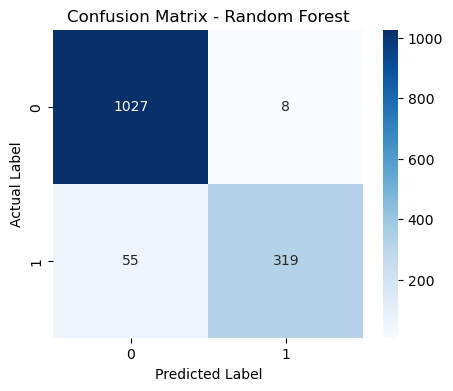

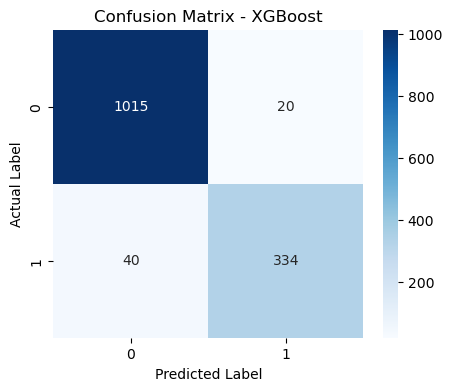

In [19]:
# =====================================================
# Generate Confusion Matrix
# =====================================================
# A confusion matrix is created for every trained model.
# =====================================================

for name, model in models.items():

    # Predict customer churn
    predictions = model.predict(X_test)

    # Generate confusion matrix
    cm = confusion_matrix(
        y_test,
        predictions
    )

    # Plot confusion matrix
    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")

    plt.xlabel("Predicted Label")

    plt.ylabel("Actual Label")

    plt.show()

# ROC Curve

The Receiver Operating Characteristic (ROC) Curve evaluates the ability of a classification model to distinguish between churn and non-churn customers.

A higher Area Under the Curve (AUC) indicates better classification performance.

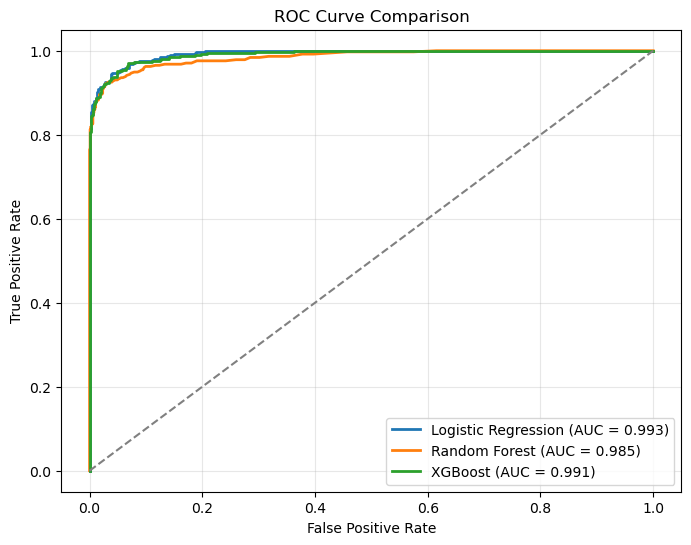

In [20]:
# =====================================================
# Plot ROC Curve for All Models
# =====================================================
# This section compares the ROC curves of all trained
# machine learning models.
# =====================================================

plt.figure(figsize=(8,6))

for name, model in models.items():

    # Predict probabilities
    y_prob = model.predict_proba(X_test)[:,1]

    # Calculate ROC values
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # Calculate ROC-AUC Score
    auc_score = roc_auc_score(y_test, y_prob)

    # Plot ROC Curve
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

# Random Guess Line
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.title("ROC Curve Comparison")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Precision-Recall Curve

The Precision-Recall Curve is useful for evaluating classification performance on imbalanced datasets.

It shows the trade-off between Precision and Recall for different probability thresholds.

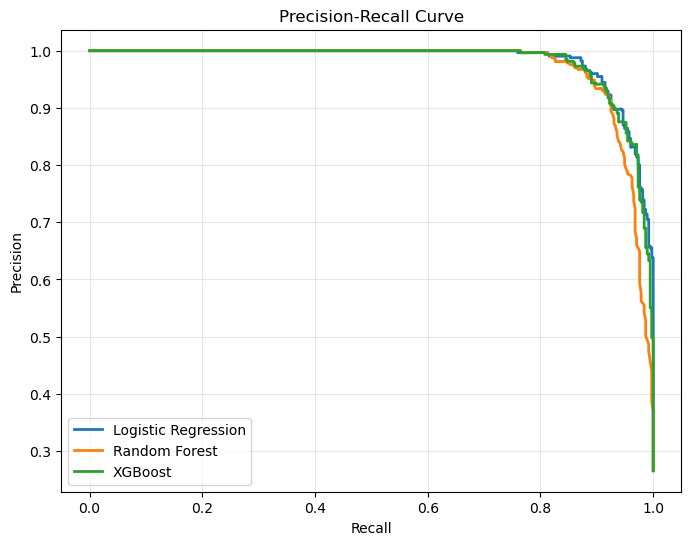

In [21]:
# =====================================================
# Plot Precision-Recall Curve
# =====================================================
# Compare Precision and Recall across all trained models.
# =====================================================

plt.figure(figsize=(8,6))

for name, model in models.items():

    # Predict probabilities
    y_prob = model.predict_proba(X_test)[:,1]

    # Calculate Precision and Recall
    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    # Plot Curve
    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=name
    )

plt.title("Precision-Recall Curve")

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

# Hyperparameter Tuning

GridSearchCV is used to identify the optimal hyperparameters for the best-performing model.

The optimized model is selected based on cross-validation performance.

# Hyperparameter Tuning using GridSearchCV

## Objective

Hyperparameter tuning is performed to optimize the performance of the best-performing machine learning model.

GridSearchCV systematically evaluates different combinations of hyperparameters using cross-validation and selects the model with the highest performance.

In [22]:
# =====================================================
# Hyperparameter Tuning for XGBoost
# =====================================================
# This section searches for the best hyperparameter
# combination using GridSearchCV.
# =====================================================

# Define the parameter grid
param_grid = {

    "model__n_estimators": [100, 200],

    "model__max_depth": [3, 5],

    "model__learning_rate": [0.05, 0.1]

}

In [23]:
# =====================================================
# Perform Grid Search
# =====================================================

grid_search = GridSearchCV(

    estimator=xgb_pipeline,

    param_grid=param_grid,

    scoring="roc_auc",

    cv=5,

    n_jobs=-1,

    verbose=1

)

grid_search.fit(

    X_train,

    y_train

)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5], 'model__n_estimators': [100, 200]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


# Optimized XGBoost Evaluation

The optimized XGBoost model is evaluated after hyperparameter tuning using a confusion matrix.

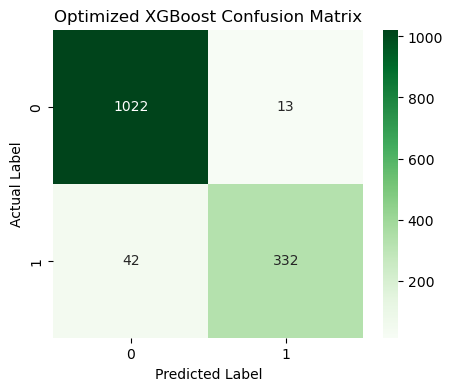

In [27]:
# =====================================================
# Confusion Matrix for Optimized XGBoost
# =====================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Optimized XGBoost Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.show()

In [28]:
# =====================================================
# Display Best Parameters
# =====================================================

print("Best Parameters")

print(grid_search.best_params_)

print()

print("Best Cross Validation Score")

print(round(grid_search.best_score_,4))

Best Parameters
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}

Best Cross Validation Score
0.9929


In [32]:
# =====================================================
# Evaluate Optimized Model
# =====================================================

best_xgb = grid_search.best_estimator_

y_pred = best_xgb.predict(X_test)

y_prob = best_xgb.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

auc = roc_auc_score(y_test, y_prob)

evaluation = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Score":[
        accuracy,
        precision,
        recall,
        f1,
        auc
    ]

})

# Display evaluation metrics
evaluation

,Metric,Score
0,Accuracy,0.960965
1,Precision,0.962319
2,Recall,0.887701
3,F1 Score,0.923505
4,ROC AUC,0.992166


# Final Observation

The optimized XGBoost model achieved the best overall performance after hyperparameter tuning.

Based on evaluation metrics and ROC-AUC score, the tuned XGBoost model is selected as the final model for deployment in the Streamlit dashboard.

In [33]:
# =====================================================
# Classification Report
# =====================================================
# Display detailed classification metrics for the
# optimized XGBoost model.
# =====================================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97      1035
           1       0.96      0.89      0.92       374

    accuracy                           0.96      1409
   macro avg       0.96      0.94      0.95      1409
weighted avg       0.96      0.96      0.96      1409



# Conclusion

The customer churn prediction models were evaluated using multiple classification metrics.

Key outcomes:

- Logistic Regression was used as the baseline model.
- Random Forest improved prediction performance.
- XGBoost achieved the best overall performance.
- Hyperparameter tuning further optimized the XGBoost model.
- The optimized model will be used for explainability and deployment in the Streamlit dashboard.